# Ejercicio1 - Busqueda de Alojamiento en Airbnb (Jupyter).

Supongamos que somos un agente de [Airbnb](http://www.airbnb.com) localizado en Lisboa, y tenemos que atender peticiones de varios clientes. Tenemos un archivo llamado `airbnb.csv` (en la carpeta data) donde tenemos información de todos los alojamientos de Airbnb en Lisboa.

In [ ]:
import pandas as pd
df_airbnb = pd.read_csv("./data/airbnb.csv")

In [ ]:
df_airbnb.head()

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,6499,14455,Entire home/apt,Belém,8,5.0,2,1.0,57.0
1,17031,66015,Entire home/apt,Alvalade,0,0.0,2,1.0,46.0
2,25659,107347,Entire home/apt,Santa Maria Maior,63,5.0,3,1.0,69.0
3,29248,125768,Entire home/apt,Santa Maria Maior,225,4.5,4,1.0,58.0
4,29396,126415,Entire home/apt,Santa Maria Maior,132,5.0,4,1.0,67.0


En concreto el dataset tiene las siguientes variables:
- room_id: el identificador de la propiedad
- host_id: el identificador del dueño de la propiedad
- room_type: tipo de propiedad (vivienda completa/(habitacion para compartir/habitación privada)
- neighborhood: el barrio de Lisboa
- reviews: El numero de opiniones
- overall_satisfaction: Puntuacion media del apartamento
- accommodates: El numero de personas que se pueden alojar en la propiedad
- bedrooms: El número de habitaciones
- price: El precio (en euros) por noche

## Ejercicios

### 1. Realizar Análisis Exploratorio de los datos

Sobre este apartado deberá explorar los datos como se vio en clase .. aplicar métodos shape, columns, etc

In [2]:
import pandas as pd
df_airbnb = pd.read_csv("./data/airbnb.csv")
df_airbnb.head()

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,6499,14455,Entire home/apt,Belém,8,5.0,2,1.0,57.0
1,17031,66015,Entire home/apt,Alvalade,0,0.0,2,1.0,46.0
2,25659,107347,Entire home/apt,Santa Maria Maior,63,5.0,3,1.0,69.0
3,29248,125768,Entire home/apt,Santa Maria Maior,225,4.5,4,1.0,58.0
4,29396,126415,Entire home/apt,Santa Maria Maior,132,5.0,4,1.0,67.0


In [3]:
df_airbnb.shape

(13232, 9)

In [4]:
df_airbnb.columns

Index(['room_id', 'host_id', 'room_type', 'neighborhood', 'reviews',
       'overall_satisfaction', 'accommodates', 'bedrooms', 'price'],
      dtype='object')

In [5]:
df_airbnb.dtypes

room_id                   int64
host_id                   int64
room_type                object
neighborhood             object
reviews                   int64
overall_satisfaction    float64
accommodates              int64
bedrooms                float64
price                   float64
dtype: object

In [6]:
df_airbnb.isnull().sum()

room_id                  0
host_id                  0
room_type                0
neighborhood             0
reviews                  0
overall_satisfaction    10
accommodates             0
bedrooms                 0
price                    0
dtype: int64

In [7]:
df_airbnb["room_type"].value_counts()
df_airbnb["neighborhood"].value_counts()

neighborhood
Santa Maria Maior          2798
Misericórdia               2402
Arroios                    1664
Santo António              1105
São Vicente                1041
Estrela                     803
Avenidas Novas              566
Penha de França             407
Campo de Ourique            319
Areeiro                     280
Belém                       254
Alvalade                    253
Parque das Nações           250
Alcântara                   213
São Domingos de Benfica     138
Lumiar                      124
Campolide                   123
Ajuda                       108
Olivais                     108
Beato                        84
Benfica                      71
Marvila                      51
Carnide                      47
Santa Clara                  23
Name: count, dtype: int64

### 2. Realizar Filtrados a Datos

- Realizar filtrados, según sea el caso. 


Nota: 
Para obtener el top de un conjunto de datos debemos aplicar un head(n) además de ordenar los datos

#### Caso 1.

Alicia va a ir a Lisboa durante una semana con su marido y sus 2 hijos. Están buscando un apartamento con habitaciones separadas para los padres y los hijos. No les importa donde alojarse o el precio, simplemente quieren tener una experiencia agradable. Esto significa que solo aceptan lugares con más de 10 críticas con una puntuación mayor de 4. Cuando seleccionemos habitaciones para Alicia, tenemos que asegurarnos de ordenar las habitaciones de mejor a peor puntuación. Para aquellas habitaciones que tienen la misma puntuación, debemos mostrar antes aquellas con más críticas. Debemos darle 3 alternativas.

In [8]:
# Filtramos 
alicia_filtro = df_airbnb[
    (df_airbnb["room_type"] == "Entire home/apt") &
    (df_airbnb["bedrooms"] >= 2) &
    (df_airbnb["reviews"] > 10) &
    (df_airbnb["overall_satisfaction"] > 4)
]

# Ordenamos: por puntuacion y luego reseñas
alicia_ordenado = alicia_filtro.sort_values(
    by=["overall_satisfaction", "reviews"],
    ascending=[False, False]
)

# Mostramos las 3 mejores alternativas
alicia_top3 = alicia_ordenado.head(3)

alicia_top3

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
120,176153,842219,Entire home/apt,Misericórdia,438,5.0,4,2.0,102.0
16,44043,192830,Entire home/apt,Santa Maria Maior,316,5.0,7,3.0,80.0
140,202150,989393,Entire home/apt,Santa Maria Maior,274,5.0,4,2.0,62.0


#### Caso 2

Roberto es un casero que tiene una casa en Airbnb. De vez en cuando nos llama preguntando sobre cuales son las críticas de su alojamiento. Hoy está particularmente enfadado, ya que su hermana Clara ha puesto una casa en Airbnb y Roberto quiere asegurarse de que su casa tiene más críticas que las de Clara. Tenemos que crear un dataframe con las propiedades de ambos. Las id de las casas de Roberto y Clara son 97503 y 90387  respectivamente. Finalmente guardamos este dataframe como excel llamado "roberto.xls

In [9]:
# Filtramos los alojamientos de Roberto y Clara
roberto_clara = df_airbnb[
    (df_airbnb["room_id"] == 97503) | (df_airbnb["room_id"] == 90387)
]

roberto_clara

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
41,90387,490050,Private room,Santo António,204,5.0,2,1.0,46.0
48,97503,515924,Private room,Santo António,39,4.0,2,1.0,26.0



#### Caso 3

Diana va a Lisboa a pasar 3 noches y quiere conocer a gente nueva. Tiene un presupuesto de 50€ para su alojamiento. Debemos buscarle las 10 propiedades más baratas, dandole preferencia a aquellas que sean habitaciones compartidas *(room_type == Shared room)*, y para aquellas viviendas compartidas debemos elegir aquellas con mejor puntuación.

In [10]:
diana_filtro = df_airbnb[df_airbnb["price"] <= 50]


In [12]:
#ordenamos
diana_ordenado = diana_filtro.sort_values(
    by=["room_type", "overall_satisfaction", "price"],
    ascending=[True, False, True]
)

In [13]:
#mostramos las mejores opciones 
diana_top10 = diana_ordenado.head(10)
diana_top10

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
6133,10630926,51540109,Entire home/apt,Estrela,51,5.0,2,0.0,18.0
9479,15490427,99448853,Entire home/apt,Santo António,19,5.0,2,1.0,23.0
9552,15565916,32747299,Entire home/apt,Alcântara,26,5.0,4,2.0,23.0
9862,15994151,6199221,Entire home/apt,São Vicente,21,5.0,2,1.0,26.0
10958,17379690,117452466,Entire home/apt,Santa Maria Maior,15,5.0,2,0.0,26.0
6144,10669972,55115529,Entire home/apt,Estrela,35,5.0,2,1.0,29.0
7593,13125854,3989352,Entire home/apt,Arroios,12,5.0,2,1.0,29.0
10123,16320810,106809604,Entire home/apt,São Vicente,5,5.0,2,1.0,29.0
10229,16440273,13219688,Entire home/apt,Misericórdia,16,5.0,4,2.0,29.0
9733,15805475,102280017,Entire home/apt,Ajuda,31,5.0,5,1.0,30.0


### 3. Realizar Agrupamientos de Datos


- Según su criterio, aplicar 2 tipos de agrupamientos a los datos brindados. 
- **Opcional**, averiguar como realizar el gráfico de los 2 agrupamientos de los datos realizados. Se podría emplear librerias como mathplot y searbon ... ayudarse de chatgtp, etc


In [14]:
#Agrupamiento 1: segun precio promedio por tipo de habitacion 

group1 = df_airbnb.groupby("room_type")["price"].mean().reset_index()

# Mostramos el resultado
print(group1)

         room_type       price
0  Entire home/apt  101.338181
1     Private room   45.629967
2      Shared room   34.397661


/tmp/ipykernel_21648/2621665207.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group1, x="room_type", y="price", palette="pastel")


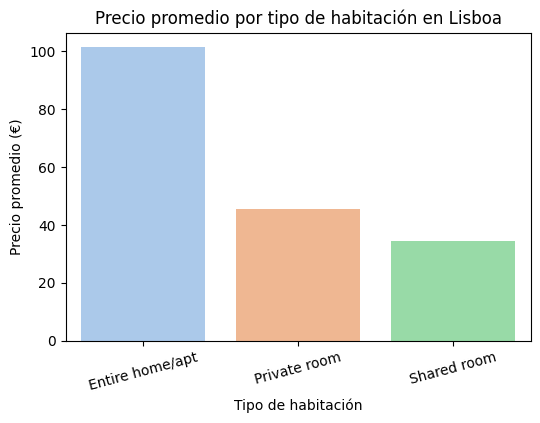

In [15]:
#gráfico
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(data=group1, x="room_type", y="price", palette="pastel")
plt.title("Precio promedio por tipo de habitación en Lisboa")
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio promedio (€)")
plt.xticks(rotation=15)
plt.show()

In [16]:
# Agrupamiento 2:  por barrio y calculamos la puntuación media
group2 = df_airbnb.groupby("neighborhood")["overall_satisfaction"].mean().reset_index()

# Ordenamos para ver los mejores barrios primero
group2 = group2.sort_values(by="overall_satisfaction", ascending=False)

# Mostramos los primeros 10
print(group2.head(10))

         neighborhood  overall_satisfaction
20  Santa Maria Maior              3.732392
0               Ajuda              3.722222
15       Misericórdia              3.695035
23        São Vicente              3.561479
12            Estrela              3.422167
21      Santo António              3.347373
6               Beato              3.297619
7               Belém              3.061024
4             Arroios              3.057797
9    Campo de Ourique              2.996865


/tmp/ipykernel_21648/1659050368.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group2.head(10), x="overall_satisfaction", y="neighborhood", palette="viridis")


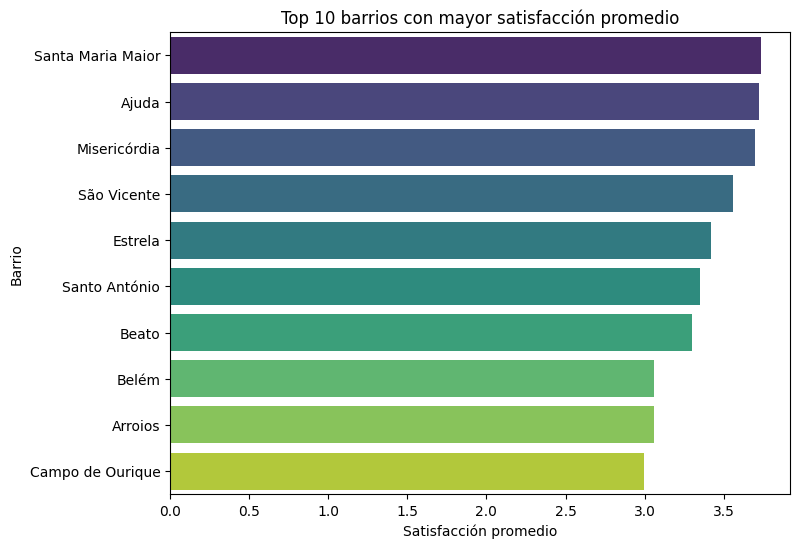

In [17]:
plt.figure(figsize=(8,6))
sns.barplot(data=group2.head(10), x="overall_satisfaction", y="neighborhood", palette="viridis")
plt.title("Top 10 barrios con mayor satisfacción promedio")
plt.xlabel("Satisfacción promedio")
plt.ylabel("Barrio")
plt.show()